# PANAGEA dataset API demo

This notebook demonstrates `ocpy.insitu.pangaea`, a small API for the
PANAGEA V3 bio-optical compilation (Valente et al. 2022,
[PANGAEA 941318](https://doi.org/10.1594/PANGAEA.941318)).

The seven `.tab` files are not packaged with `ocpy`; the loader resolves
them from `$OS_COLOR/PANAGEA/V3/datasets/` (or an explicit `path=`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ocpy.insitu import pangaea

## The 7 datasets

Reference any dataset by a short key instead of its long filename.

In [2]:
pangaea.file_catalog()

{'chla': 'insitudb_chla_V3.tab',
 'rrs': 'insitudb_rrs_V3.tab',
 'rrs_sat2': 'insitudb_rrs_satbands2_V3.tab',
 'rrs_sat6': 'insitudb_rrs_satbands6_V3.tab',
 'iop': 'insitudb_iopskdtsm_V3.tab',
 'iop_sat2': 'insitudb_iopskdtsm_satbands2_V3.tab',
 'iop_sat6': 'insitudb_iopskdtsm_satbands6_V3.tab'}

### A small helper

Not every observation has every measurement, so for a clear demo we pick
the observation with the most finite points for a given variable family.

In [3]:
def best_obs(df, kind):
    """Return the ID with the most finite values for `kind`."""
    meta = pangaea.column_metadata(df)
    cols = [n for n, m in meta.items()
            if m.get('variable') == kind
            and m.get('role') in ('spectral', 'spectral_band')]
    return df[cols].notna().sum(axis=1).idxmax()

## Load chlorophyll-a

The frame is indexed by the global observation `ID` and uses friendly
column names. Note the two chlorophyll methods are kept separate
(`chla_hplc`, `chla_fluor`).

In [4]:
df_chla = pangaea.load('chla')
print(df_chla.shape)
df_chla[['lat', 'lon', 'date_time', 'chla_hplc', 'chla_fluor']].head()

(82543, 14)


,lat,lon,date_time,chla_hplc,chla_fluor
ID,,,,,
1,-64.81500,-64.04100,1997-01-02 12:48:00,0.7623,1.43685
2,-53.34202,-67.40648,1997-01-05 15:51:00,NaN,0.92045
3,-53.36000,-67.31300,1997-01-05 16:36:00,NaN,0.99230
4,-53.53112,-67.11405,1997-01-05 17:44:00,NaN,2.16580
5,-53.74975,-66.85192,1997-01-05 19:16:00,NaN,1.26560


## Load Rrs and plot one spectrum

`spectrum()` returns a wavelength-indexed `pandas.Series` for a single
observation, with missing wavelengths dropped — ready to plot or fit.

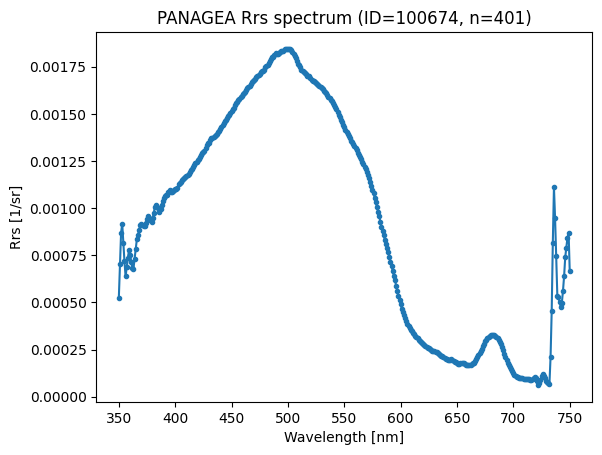

In [5]:
df_rrs = pangaea.load('rrs')

obs_id = best_obs(df_rrs, 'rrs')
spec = pangaea.spectrum(df_rrs, obs_id, kind='rrs')

fig, ax = plt.subplots()
ax.plot(spec.index, spec.values, marker='.')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [1/sr]')
ax.set_title(f'PANAGEA Rrs spectrum (ID={obs_id}, n={len(spec)})')
plt.show()

## Satellite-band Rrs

For the sat-band files the true wavelength of each band lives in a paired
`Lambda` column; `spectrum()` uses that per-row wavelength automatically.

Note: several sensors (SeaWiFS, MODIS, VIIRS, OLCI, MERIS) define bands at
nearly the same nominal wavelength, so a sat-band spectrum can contain
repeated wavelengths — one per sensor band. Group by wavelength if you want
a single value per wavelength.

In [6]:
df_sat = pangaea.load('rrs_sat2')
obs_id = best_obs(df_sat, 'rrs')
spec_sat = pangaea.spectrum(df_sat, obs_id, kind='rrs')
# Collapse repeated wavelengths (one mean value per wavelength).
spec_sat.groupby(spec_sat.index).mean()

wavelength
399.0    0.007227
409.0    0.006223
412.0    0.006022
442.0    0.005406
445.0    0.005204
485.0    0.004388
489.0    0.004386
509.0    0.002699
552.0    0.001399
555.0    0.001399
559.0    0.001299
619.0    0.000200
665.0    0.000100
672.0    0.000200
675.0    0.000200
682.0    0.000100
709.0    0.000000
745.0    0.000000
755.0    0.000000
778.0    0.000000
Name: 144503, dtype: float64

## Inherent optical properties

The IOP file carries several variable families. Extract any of them with
the `kind` argument: `'aph'`, `'acdom'`, `'bbp'`, `'kd'`.

In [7]:
df_iop = pangaea.load('iop')
obs_id = best_obs(df_iop, 'aph')
aph = pangaea.spectrum(df_iop, obs_id, kind='aph')
print(f'ID={obs_id}, n={len(aph)} aph points')
aph.head()

ID=132360, n=2280 aph points


wavelength
290.0    0.012675
290.2    0.012620
290.4    0.012445
290.6    0.012645
290.8    0.012585
Name: 132360, dtype: float64

## Long-format reshape and column metadata

`to_long()` gives a tidy `[ID, wavelength, value, sensor, band]` frame for
cross-observation analysis, and `column_metadata()` exposes the original
PANGAEA names, units and parsed attributes.

In [8]:
long = pangaea.to_long(df_rrs, kind='rrs')
print(long.shape)
long.head()

(642123, 5)


,ID,wavelength,value,sensor,band
32037,94958,313.0,0.003783,None,None
32051,94977,313.0,0.002224,None,None
32067,95001,313.0,0.002131,None,None
32095,95034,313.0,0.002794,None,None
32114,95072,313.0,0.002949,None,None


In [9]:
meta = pangaea.column_metadata(df_rrs)
# Inspect metadata for one spectral column.
name = next(k for k, m in meta.items() if m.get('role') == 'spectral')
name, meta[name]

('rrs_313',
 {'orig': 'RRS [1/sr] (at 313nm)',
  'friendly': 'rrs_313',
  'role': 'spectral',
  'variable': 'rrs',
  'unit': '1/sr',
  'long_name': 'RRS',
  'wavelength': 313.0,
  'sensor': None,
  'band': None})